In [ ]:
from pyspark.sql import SparkSession
spark = SparkSession.builder.appName('Pertemuan9').getOrCreate()

data = [
    ('James', 34, 'M', 3000, 1),
    ('Anna', 28, 'F', 4100, 2),
    ('Lee', 23, 'M', 2700, 1)
]
columns = ['Name', 'Age', 'Gender', 'Salary', 'DeptId']
df = spark.createDataFrame(data, schema=columns)
df.createOrReplaceTempView('employees')
spark.sql('SELECT * FROM employees').show()
spark.sql('SELECT Name, Age FROM employees WHERE Salary > 3000').show()
spark.sql('SELECT AVG(Salary) FROM employees').show()


+-----+---+------+------+------+
| Name|Age|Gender|Salary|DeptId|
+-----+---+------+------+------+
|James| 34|     M|  3000|     1|
| Anna| 28|     F|  4100|     2|
|  Lee| 23|     M|  2700|     1|
+-----+---+------+------+------+

+----+---+
|Name|Age|
+----+---+
|Anna| 28|
+----+---+

+------------------+
|       avg(Salary)|
+------------------+
|3266.6666666666665|
+------------------+



In [ ]:
spark.sql('''
SELECT Gender, SUM(Salary) as TotalSalary, Age
FROM employees
GROUP BY Gender, Age
ORDER BY Age
''').show()


+------+-----------+---+
|Gender|TotalSalary|Age|
+------+-----------+---+
|     M|       2700| 23|
|     F|       4100| 28|
|     M|       3000| 34|
+------+-----------+---+



In [ ]:
spark.sql('''
SELECT Name, Age, Salary, ROW_NUMBER() OVER (PARTITION BY Age ORDER BY Salary DESC) as rank
FROM employees
''').show()


+-----+---+------+----+
| Name|Age|Salary|rank|
+-----+---+------+----+
|  Lee| 23|  2700|   1|
| Anna| 28|  4100|   1|
|James| 34|  3000|   1|
+-----+---+------+----+



In [ ]:
from pyspark.sql import SparkSession
spark = SparkSession.builder.appName('Pertemuan9').getOrCreate()

# Data setup for complex SQL queries
employees = spark.createDataFrame([
    ('James', 34, 'M', 3000, 1),
    ('Anna', 28, 'F', 4100, 2),
    ('Lee', 23, 'M', 2700, 1)
], ['Name', 'Age', 'Gender', 'Salary', 'DeptId'])
departments = spark.createDataFrame([
    (1, 'HR'),
    (2, 'Marketing')
], ['DeptId', 'DeptName'])
projects = spark.createDataFrame([
    (1, 'Project A'),
    (2, 'Project B')
], ['DeptId', 'ProjectName'])
employees.createOrReplaceTempView('employees')
departments.createOrReplaceTempView('departments')
projects.createOrReplaceTempView('projects')

# Complex SQL query involving multiple joins and subqueries
spark.sql('''
SELECT e.Name, e.Age, d.DeptName, p.ProjectName
FROM employees e
JOIN departments d ON e.DeptId = d.DeptId
JOIN projects p ON e.DeptId = p.DeptId
''').show()


+-----+---+---------+-----------+
| Name|Age| DeptName|ProjectName|
+-----+---+---------+-----------+
|  Lee| 23|       HR|  Project A|
|James| 34|       HR|  Project A|
| Anna| 28|Marketing|  Project B|
+-----+---+---------+-----------+



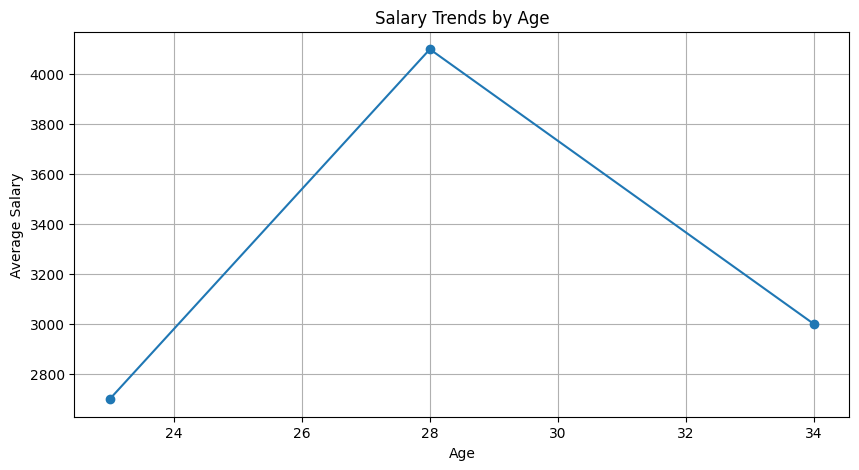

In [7]:
import matplotlib.pyplot as plt
import pandas as pd

salary_trends = spark.sql('''
SELECT Age, AVG(Salary) AS AverageSalary
FROM employees
GROUP BY Age
ORDER BY Age
''').toPandas()

plt.figure(figsize=(10, 5))
plt.plot(salary_trends['Age'], salary_trends['AverageSalary'], marker='o')
plt.xlabel('Age')
plt.ylabel('Average Salary')
plt.title('Salary Trends by Age')
plt.grid(True)
plt.show()


+----------+-----------+-------------+
|Department|TotalSalary|EmployeeCount|
+----------+-----------+-------------+
|        HR|      12900|            4|
|   Finance|      16500|            3|
|        IT|      12700|            3|
+----------+-----------+-------------+



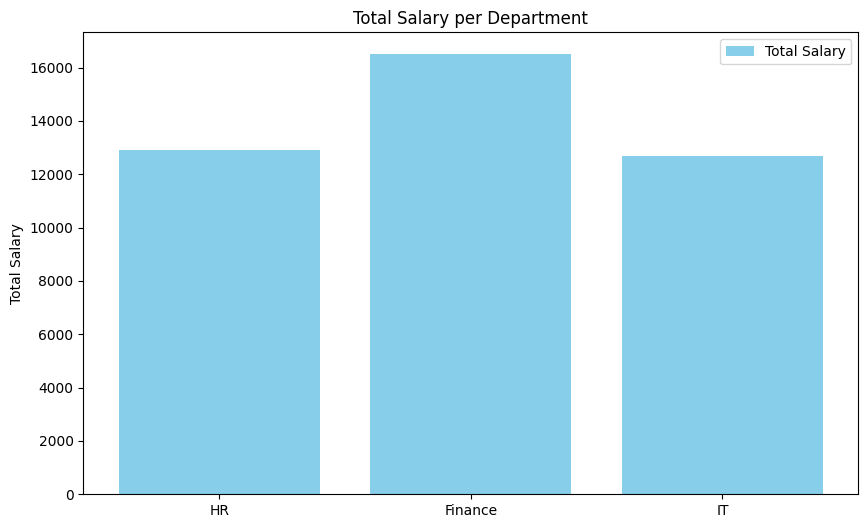

In [8]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import avg, count, sum, col
import matplotlib.pyplot as plt

data = [
    (1, "Alice", 25, "HR", 3000),
    (2, "Bob", 30, "IT", 4000),
    (3, "Charlie", 35, "Finance", 5000),
    (4, "David", 28, "HR", 3200),
    (5, "Eve", 40, "IT", 4500),
    (6, "Frank", 50, "Finance", 6000),
    (7, "Grace", 29, "HR", 3100),
    (8, "Hank", 33, "IT", 4200),
    (9, "Ivy", 38, "Finance", 5500),
    (10, "John", 45, "HR", 3600)
]
columns = ["ID", "Name", "Age", "Department", "Salary"]

df = spark.createDataFrame(data, columns)
df.createOrReplaceTempView("employees")

result_task1 = spark.sql("""
    SELECT Department, SUM(Salary) AS TotalSalary, COUNT(*) AS EmployeeCount
    FROM employees
    GROUP BY Department
""")
result_task1.show()

result_task1_pd = result_task1.toPandas()
plt.figure(figsize=(10, 6))
plt.bar(result_task1_pd["Department"], result_task1_pd["TotalSalary"], color="skyblue", label="Total Salary")
plt.ylabel("Total Salary")
plt.title("Total Salary per Department")
plt.legend()
plt.show()

+------------+-------+------+
|    AgeGroup|   Name|Salary|
+------------+-------+------+
|         30s|Charlie|  5000|
|         30s|    Ivy|  5500|
|40 and Above|  Frank|  6000|
|    Under 30|  David|  3200|
+------------+-------+------+



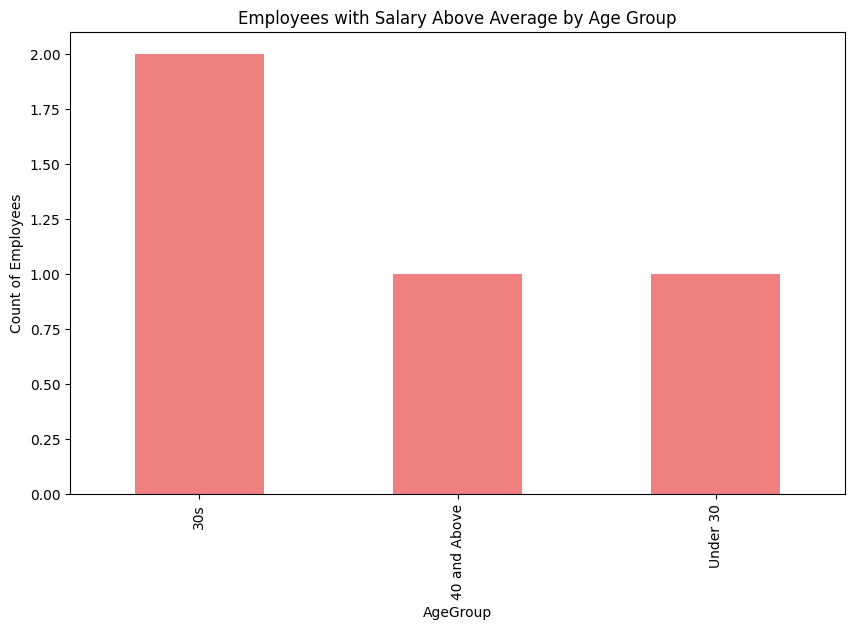

In [9]:
result_task2 = spark.sql("""
    SELECT AgeGroup, Name, Salary
    FROM (
        SELECT
            CASE
                WHEN Age < 30 THEN 'Under 30'
                WHEN Age BETWEEN 30 AND 39 THEN '30s'
                ELSE '40 and Above'
            END AS AgeGroup,
            Name, Salary, AVG(Salary) OVER (PARTITION BY CASE
                WHEN Age < 30 THEN 'Under 30'
                WHEN Age BETWEEN 30 AND 39 THEN '30s'
                ELSE '40 and Above'
            END) AS AvgSalary
        FROM employees
    )
    WHERE Salary > AvgSalary
""")
result_task2.show()

result_task2_pd = result_task2.toPandas()
plt.figure(figsize=(10, 6))
result_task2_pd.groupby("AgeGroup")["Name"].count().plot(kind="bar", color="lightcoral")
plt.ylabel("Count of Employees")
plt.title("Employees with Salary Above Average by Age Group")
plt.show()

+----------+-------------+-----------------+-----------+
|Department|EmployeeCount|        AvgSalary|TotalSalary|
+----------+-------------+-----------------+-----------+
|        HR|           33|4830.818181818182|     159417|
|   Finance|           43|5048.953488372093|     217105|
|        IT|           34|4983.470588235294|     169438|
+----------+-------------+-----------------+-----------+



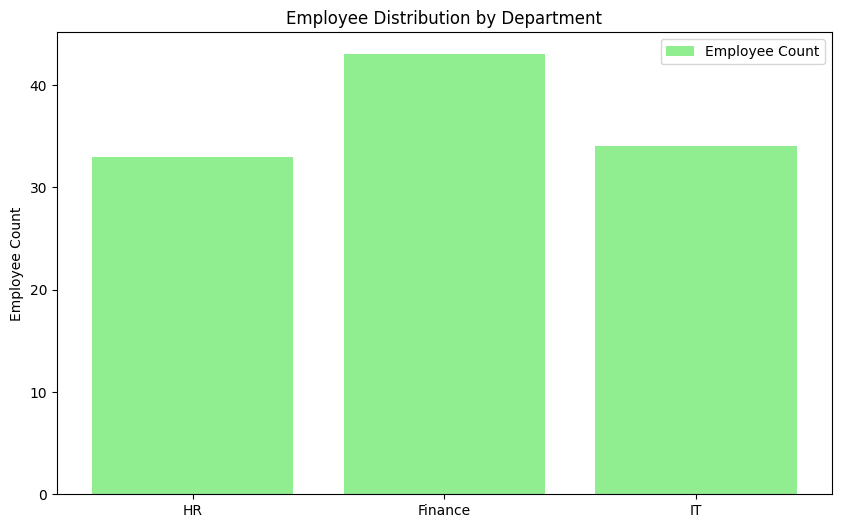

In [11]:
import random

random_data = [
    (i, f"Employee{i}", random.randint(20, 60), random.choice(["HR", "IT", "Finance"]), random.randint(3000, 7000))
    for i in range(101, 201)
]

df_large = spark.createDataFrame(data + random_data, columns)
df_large.createOrReplaceTempView("employees_large")

result_task3 = spark.sql("""
    SELECT e1.Department, COUNT(e1.ID) AS EmployeeCount, AVG(e1.Salary) AS AvgSalary, SUM(e1.Salary) AS TotalSalary
    FROM employees_large e1
    GROUP BY e1.Department
""")
result_task3.show()

result_task3_pd = result_task3.toPandas()
plt.figure(figsize=(10, 6))
plt.bar(result_task3_pd["Department"], result_task3_pd["EmployeeCount"], color="lightgreen", label="Employee Count")
plt.ylabel("Employee Count")
plt.title("Employee Distribution by Department")
plt.legend()
plt.show()

spark.stop()